# Reto 2 · Limpieza de datos

**Notebook 02.** Convierte la tabla cruda en tablas limpias, trazables y reproducibles para el fenotipado (capas A y B), las trayectorias y el clasificador. Los problemas que resuelve salen del notebook 01 (análisis exploratorio).

Principios:
- **Nada se borra en silencio.** Cada regla deja una entrada en `registro_limpieza` con el N afectado por registro. Las medidas descartadas siguen en la tabla, con `excluida = True` y su motivo.
- **La ausencia estructural no se imputa.** Si un registro no recoge una variable, se marca como `no_recogida`, que es distinto de `falta`.
- **Ningún número mágico.** Umbrales, ventanas, rangos y columnas por visita están en `config.yaml`. La justificación de cada regla está en `docs/registro_decisiones.md`.

| Regla | Qué hace |
|---|---|
| R01 | Códigos "se desconoce" (9, 9999, 99999) y sexo no especificado → ausente |
| R02 | Edad: tramo ordinal y grupo amplio; tramos que cruzan grupos → grupo ausente |
| R03 | Fechas con formato explícito por registro; `dias_alta` = fecha de la prueba − alta |
| R04 | Fechas anteriores al alta → fuera del análisis temporal |
| R05 | Valores fuera del rango plausible → medida excluida |
| R06 | Prueba duplicada en pacientes compartidos → se queda la del registro socio |
| R07 | `cohorte_analisis`: cada paciente en un solo lado de la replicación |
| R08 | Supervivencia al alta; exitus con seguimiento → inconsistente |
| R09 | Cumplimentación de CIBERESUCICOVID (`IH_PorcCMD` ≥ 50; ≥ 99 como sensibilidad) |
| R10 | TAC: solo formularios completos o TAC realizados; fibrosis estricta y amplia |
| R11 | Ausencia estructural (`no_recogida`) frente a `falta` |
| R12 | TENACITY: abandono frente a "aún no le toca" la visita |
| R13 | Estado en la ventana de definición (60–210 días) y banderas de inclusión de las capas A y B |
| R14 | Preguntas condicionadas: fatiga = 0 deducida si la resolución clínica es total (CIBERESUCICOVID) |

> **Privacidad.** Solo se muestran agregados, con supresión de recuentos < 10. Las tablas limpias se guardan en `datos_procesados/`, fuera del control de versiones.

## 0 · Entorno

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, limpieza, privacidad

cfg = carga.cargar_config()
N_MIN = cfg["privacidad"]["n_minimo_celda"]
REG = list(cfg["registros"])
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida",
       "TENACITY": "TENACITY", "VIRGEN_DEL_ROCIO": "Virgen del Rocío"}
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 110)


def nota(ax, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    ax.figure.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")

## 1 · Aplicar la limpieza

In [2]:
tablas = limpieza.limpiar(cfg)
pacientes, medidas, estado = tablas["pacientes"], tablas["medidas"], tablas["estado_definicion"]
for nombre, t in tablas.items():
    print(f"{nombre:<20} {t.shape[0]:>7,} filas × {t.shape[1]:>3} columnas")

pacientes              9,809 filas ×  53 columnas
medidas               86,810 filas ×  14 columnas
estado_definicion      9,809 filas ×  38 columnas
visitas_tenacity         861 filas ×   4 columnas
registro_limpieza         33 filas ×   8 columnas
flujo_consort              7 filas ×   5 columnas


## 2 · Registro de reglas

Cada fila es una regla aplicada y el número de casos afectados, por registro de análisis (en las tablas de pacientes) o por registro de origen (en las medidas).

In [3]:
reg = tablas["registro_limpieza"].copy()
reg.columns = [ETQ.get(c.removeprefix("N_"), c) for c in reg.columns]
cols_n = ["N", *[ETQ[r] for r in REG if ETQ[r] in reg.columns]]
reg = privacidad.suprimir_celdas(reg, N_MIN, cols_n)
reg.to_csv(TAB / "02_registro_limpieza.csv", index=False)
reg.set_index(["regla", "tabla"])

descripcion      N CIBERESUCICOVID POSTCOVID-Lleida TENACITY Virgen del Rocío
regla tabla                                                                                                                                                                                      
R01   pacientes                                                                                  nu_tabaquismo: código 9 -> NaN    552             548              <10        0                0
      pacientes                                                                                 nu_exitus_hosp: código 9 -> NaN    <10             <10                0        0                0
      pacientes                                                                                sexo: 2 (no especificado) -> NaN      0               0                0        0                0
      pacientes                                                                             nu_sexo: 2 (no especificado) -> NaN      0               0                0        0                0
R02   pacientes                                    Tramo de edad que cruza grupos -> grupo_edad NaN (tramo original conservado)     39             <10                0       20               14
R07   pacientes                                                    fusionada_lleida == 1 -> cohorte_analisis = POSTCOVID_LLEIDA    437               0              437        0                0
      pacientes                                                  enriquecida_vrocio == 1 -> cohorte_analisis = VIRGEN_DEL_ROCIO     22               0                0        0               22
R04   pacientes                                         visita_dias < 0 -> visita_dias_valida NaN (fuera del análisis temporal)     54              47              <10      <10              <10
R08   pacientes                                                                    Exitus hospitalario -> superviviente = False   2233            2233                0        0                0
R09   pacientes                                                           CIBERESUCICOVID con IH_PorcCMD < 50 -> cmd_ok = False   2729            2729                0        0                0
R03   medidas                                                  Fecha de la prueba ausente: se usa visita_dias (solo 1.ª visita)     92              80              <10      <10              <10
      medidas                                        Sin fecha ni visita_dias: válida, pero fuera de cualquier ventana temporal  20260           20079              165       16                0
R01   medidas                                                                               Valor [9999, 99999] (no disponible)      0               0                0        0                0
      medidas                                                                             resolucion: código [3] (se desconoce)   1071            1071                0        0                0
R04   medidas                                                                                 Medida con fecha anterior al alta    793             753               12      <10               20
R05   medidas                                                                                   Valor fuera del rango plausible     39              23               10      <10              <10
R06   medidas           Medida de CIBERESUCICOVID repetida en el registro socio (|Δdías| <= 30); valor idéntico (±1) en el 97 %    953             953                0        0                0
R14   medidas                                    fatiga = 0 deducida cuando resolucion = 0 (pregunta condicionada del cuaderno)   2003            2003                0        0                0
R10   medidas                                                 TENACITY M3: formulario de TAC no completo (ceros = sin rellenar)    252               0                0      252                0
      medidas                             

**Lectura.**
- **R06 es la regla de más impacto sobre las medidas.** Se eliminan cerca de 950 pruebas de CIBERESUCICOVID que son la misma prueba registrada en Lleida o en Virgen del Rocío (el 97 % con valor idéntico ±1). Sin esta regla, los pacientes compartidos pesarían el doble en las trayectorias.
- **R10 descarta miles de visitas sin TAC o con el formulario incompleto.** Son casillas a 0 que no significan "sin hallazgos".
- **R09 y R08 definen la población de CIBERESUCICOVID:** 2.233 exitus hospitalarios y unos 2.700 registros con poca cumplimentación (casi sin seguimiento, ver el notebook 01, §2.1).
- **R08:** 3 pacientes tienen exitus hospitalario y medidas de seguimiento. Quedan fuera del fenotipado hasta que el equipo lo revise.

## 3 · Flujo de pacientes (CONSORT)

In [4]:
consort = tablas["flujo_consort"].rename(columns=ETQ)
consort.to_csv(TAB / "02_flujo_consort.csv")
privacidad.suprimir_celdas(consort, N_MIN, list(consort.columns))

cohorte_analisis,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY,Virgen del Rocío,Total
1. Pacientes únicos,8815,624,287,83,9809
2. Supervivientes al alta,6582,624,287,83,7576
3. Sin inconsistencias,6582,624,287,83,7576
4. Cumplimentación suficiente (CMD ≥ 50 en CIBERESUCICOVID),4077,624,287,83,5071
5. Con alguna medida de seguimiento válida,3589,623,203,79,4494
6. Capa A: DLCO o FVC en la ventana de definición,1352,556,159,47,2114
7. Capa B: además HADS o mMRC en la ventana,0,532,155,23,710


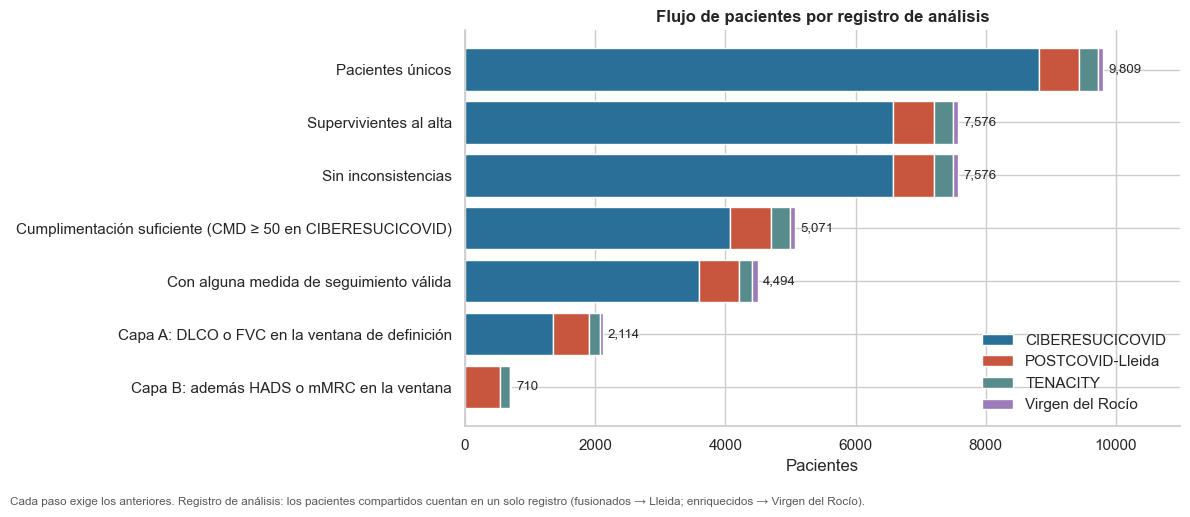

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
datos = tablas["flujo_consort"][REG]
y = np.arange(len(datos))
izquierda = np.zeros(len(datos))
for r in REG:
    ax.barh(y, datos[r], left=izquierda, color=COLOR[r], label=ETQ[r], edgecolor="white")
    izquierda += datos[r].values
for i, total in enumerate(izquierda):
    ax.text(total + 80, i, f"{int(total):,}", va="center", fontsize=9.5)
ax.set_yticks(y, [p.split(". ", 1)[1] for p in datos.index]); ax.invert_yaxis()
ax.set_xlabel("Pacientes"); ax.set_xlim(0, izquierda.max() * 1.12)
ax.set_title("Flujo de pacientes por registro de análisis")
ax.legend(frameon=False, loc="lower right")
nota(ax, "Cada paso exige los anteriores. Registro de análisis: los pacientes compartidos cuentan en un solo registro "
         "(fusionados → Lleida; enriquecidos → Virgen del Rocío).")
plt.tight_layout(); fig.savefig(FIG / "02_flujo_consort.png", bbox_inches="tight", dpi=150); plt.show()

**Lectura.**
- **CIBERESUCICOVID se queda en unos 1.350 pacientes** para la capa A (de 8.815). Las mayores pérdidas vienen de la mortalidad, de la falta de seguimiento y de que la DLCO no se mide en todos los centros.
- **Capa B (multidominio): unos 530 pacientes de Lleida y 155 de TENACITY.** CIBERESUCICOVID no aporta a la capa B porque no recoge HADS ni mMRC. Virgen del Rocío aporta unos 20 pacientes con mMRC, pero se usará solo como complemento.

## 4 · Medidas: qué se conserva y qué se excluye

In [6]:
resumen = (medidas.assign(motivo=medidas["motivo_exclusion"].fillna("válida"))
           .groupby(["variable", "motivo"]).size().unstack(fill_value=0))
resumen = resumen[["válida"] + [c for c in limpieza.MOTIVOS if c in resumen.columns]]
resumen["% excluidas"] = (100 * (1 - resumen["válida"] / resumen.sum(axis=1))).round(1)
privacidad.suprimir_celdas(resumen, N_MIN, [c for c in resumen.columns if c != "% excluidas"])

motivo,válida,codigo_no_disponible,dias_negativos,fuera_de_rango,duplicado_entre_registros,% excluidas
variable,,,,,,
astenia,2043,0,<10,0,0,0.1
compl_cardiovascular,6853,0,105,0,0,1.5
compl_infecciosa,6854,0,105,0,0,1.5
dlco,4181,0,42,10,313,8.0
fatiga,5775,0,70,0,0,1.2
fatiga_muscular,1625,0,<10,0,0,0.1
fev1,4737,0,52,11,320,7.5
fibrosis_amplia,815,0,0,0,0,0.0
fibrosis_estricta,815,0,0,0,0,0.0


In [7]:
validas = medidas[~medidas["excluida"]]
n_pac = validas.groupby(["variable", "registro"], observed=True)["subject_id"].nunique().unstack(fill_value=0)
n_pac = n_pac.rename(columns=ETQ)
print("Pacientes con al menos una medida válida (registro de origen de la medida):")
privacidad.suprimir_celdas(n_pac, N_MIN, list(n_pac.columns))

Pacientes con al menos una medida válida (registro de origen de la medida):


registro,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY,Virgen del Rocío
variable,,,,
astenia,0,596,183,0
compl_cardiovascular,3703,0,0,0
compl_infecciosa,3701,0,0,0
dlco,1560,593,176,55
fatiga,3327,0,0,0
fatiga_muscular,0,596,0,0
fev1,1878,603,179,61
fibrosis_amplia,0,301,53,0
fibrosis_estricta,0,301,53,0


In [8]:
dl = validas[validas["variable"] == "dlco"]
print(f"DLCO válida: {len(dl):,} medidas en {dl['subject_id'].nunique():,} pacientes; "
      f"con ≥ 2 medidas: {(dl.groupby('subject_id').size() >= 2).sum():,}")
print(f"Medidas sin tiempo (dias_alta ausente): {int(validas['dias_alta'].isna().sum())}")

DLCO válida: 4,181 medidas en 2,371 pacientes; con ≥ 2 medidas: 1,070
Medidas sin tiempo (dias_alta ausente): 20409


## 5 · Estado en la ventana de definición

Para cada paciente y variable se toma la **primera medida válida entre 60 y 210 días** tras el alta y se clasifica con el umbral clínico. La disponibilidad distingue:
- `medida`: hay valor en la ventana.
- `falta`: el registro recoge la variable, pero este paciente no tiene valor en la ventana.
- `no_recogida`: el registro no recoge la variable (ausencia estructural, nunca se imputa).

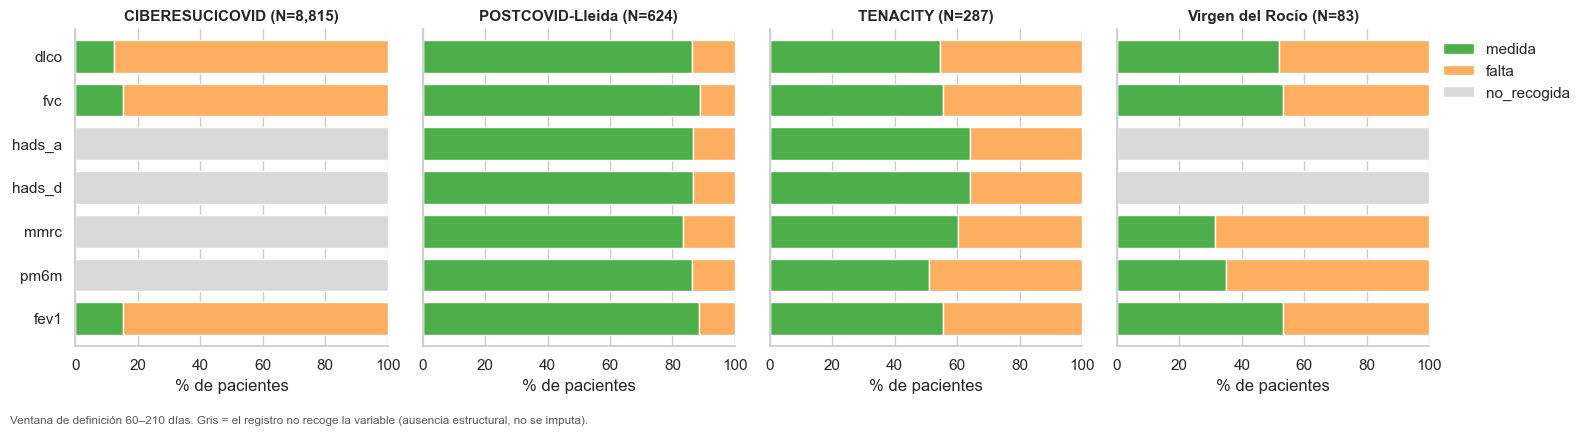

In [9]:
variables = cfg["variables_definicion"]["capa_A"] + cfg["variables_definicion"]["capa_B_extra"] + ["fev1"]
disp = (estado.melt(id_vars="cohorte_analisis", value_vars=[f"{v}_disp" for v in variables], var_name="variable", value_name="disp")
        .assign(variable=lambda d: d["variable"].str.replace("_disp", "")))
pct = (disp.groupby(["variable", "cohorte_analisis"], observed=True)["disp"].value_counts(normalize=True)
       .unstack(fill_value=0) * 100)

fig, axes = plt.subplots(1, len(REG), figsize=(16, 4.2), sharey=True)
colores = {"medida": "#4daf4a", "falta": "#fdae61", "no_recogida": "#d9d9d9"}
for ax, r in zip(axes, REG):
    d = pct.xs(r, level="cohorte_analisis").reindex(variables).reindex(columns=list(colores), fill_value=0)
    d.plot.barh(stacked=True, ax=ax, color=list(colores.values()), width=0.75, legend=False, edgecolor="white")
    n = int((pacientes["cohorte_analisis"] == r).sum())
    ax.set_title(f"{ETQ[r]} (N={n:,})", fontsize=11); ax.set_xlabel("% de pacientes"); ax.set_xlim(0, 100)
axes[0].invert_yaxis(); axes[0].set_ylabel("")
axes[-1].legend(list(colores), frameon=False, bbox_to_anchor=(1, 1))
nota(axes[0], f"Ventana de definición {cfg['tiempo']['ventana_definicion_dias'][0]}–{cfg['tiempo']['ventana_definicion_dias'][1]} días. "
              "Gris = el registro no recoge la variable (ausencia estructural, no se imputa).")
plt.tight_layout(); fig.savefig(FIG / "02_disponibilidad_ventana.png", bbox_inches="tight", dpi=150); plt.show()

In [10]:
# Prevalencia de alteración en la ventana, solo pacientes incluibles en la capa A
inc = estado.merge(pacientes[["subject_id", "incluible_A", "incluible_B"]], on="subject_id")
filas = []
for v in variables:
    for r in REG:
        s = inc.loc[(inc["cohorte_analisis"] == r) & inc["incluible_A"], f"{v}_alterada"].dropna()
        k = int(s.sum())
        if len(s) >= N_MIN and (k == 0 or k >= N_MIN):
            filas.append({"variable": v, "registro": ETQ[r], "N": len(s), "% alterada": round(100 * k / len(s), 1)})
prev = pd.DataFrame(filas).pivot(index="variable", columns="registro", values="% alterada").reindex(variables)
prev

registro,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY,Virgen del Rocío
variable,,,,
dlco,63.1,70.8,46.8,83.7
fvc,30.9,43.6,38.4,36.4
hads_a,NaN,17.0,19.5,NaN
hads_d,NaN,13.1,12.0,NaN
mmrc,NaN,23.1,18.7,NaN
pm6m,NaN,35.7,46.5,0.0
fev1,24.5,30.9,42.8,22.7


Estas prevalencias son **el punto de partida del fenotipado**. En la misma ventana temporal y con los mismos umbrales clínicos, las diferencias entre registros son diferencias de población, no de momento de medida. Por ejemplo, TENACITY tiene menos DLCO alterada que CIBERESUCICOVID y Lleida.

## 6 · TENACITY: abandono frente a "aún no le toca"

In [11]:
vt = tablas["visitas_tenacity"]
print(f"Fecha de corte estimada (última visita registrada, fechas desplazadas ±30 d): {vt.attrs.get('corte', 'n/d')}")
tab_vt = pd.crosstab(vt["visita"], vt["estado"]).reindex(["M3", "M6", "A1"])
privacidad.suprimir_celdas(tab_vt, N_MIN, list(tab_vt.columns))

Fecha de corte estimada (última visita registrada, fechas desplazadas ±30 d): 2026-07-19


estado,abandono,no_le_toca,realizada,sin_dato,sin_fecha_alta
visita,,,,,
M3,41,0,209,19,18
M6,11,21,137,100,18
A1,30,57,121,61,18


- **No le toca:** en las visitas de 6 y 12 meses, una parte de los pacientes "sin visita" todavía no ha llegado a la fecha. Contarlos como abandono inflaría la pérdida de seguimiento y sesgaría la corrección por abandono informativo (IPW).
- **Sin dato:** pacientes ya debidos, sin visita y sin `perdida_seg`. Lo prudente es tratarlos como abandono no declarado.

## 7 · Guardar

In [12]:
carpeta = limpieza.guardar(tablas, cfg)
print(f"Tablas guardadas en {carpeta.relative_to(RAIZ)}/ (ignorado por git):")
for p in sorted(carpeta.glob("*.parquet")):
    print(f"  {p.name}")

Tablas guardadas en ..\Datos limpios/ (ignorado por git):
  estado_definicion.parquet
  fenotipos.parquet
  flujo_consort.parquet
  medidas.parquet
  pacientes.parquet
  registro_limpieza.parquet
  visitas_tenacity.parquet


### Uso en los siguientes notebooks

```python
import pandas as pd
pacientes = pd.read_parquet("datos_procesados/pacientes.parquet")
estado = pd.read_parquet("datos_procesados/estado_definicion.parquet")
medidas = pd.read_parquet("datos_procesados/medidas.parquet").query("~excluida")
capa_A = estado[estado["subject_id"].isin(pacientes.loc[pacientes["incluible_A"], "subject_id"])]
```

**Pendiente de validación clínica** (`docs/registro_decisiones.md`):
- Que un formulario de TAC completo sin lesión marcada signifique "sin lesión".
- La asignación de los pacientes compartidos a Lleida y Virgen del Rocío.
- Los 3 casos de exitus con seguimiento.
- Que la PM6M < 100 m se considere no plausible.